<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/voluntarios/Voluntario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Formación de las galaxias a partir de sistemas solares**

**Resumen**

Este ejercicio consiste en simular la evolución de una galaxia, compuesta por un agujero negro supermasivo central, y N sistemas solares en órbita. Se considera la atracción central del agujero negro y las interacciones entre sistemas solares. Por eficiencia, la interacción entre sistemas solares solo se calculará para sistemas cercanos entre sí. La dinámica esta regida por la segunda Ley de Newton, teniendo en cuenta las posibles colisiones elásticas, en las que se conserva la energía cinética y el momento lineal. Se implementa el algoritmo de Verlet en Velocidad. La elección de este método se basa en su eficiencia computacional, pero sobretodo en que garantiza la conservación de la energía y momento angular. Se analizará la evolución del momento angular del sistema, la densidad de Masa Radial, y el Flujo de Masa.

**Fundamento teórico**

*1. Dinámica del sistema de N Cuerpos*

El modelo describe una galaxia, compuesta por un agujero negro masivo centrall, y N pequeños cuerpos (sistemas solares), orbitando alrededor de éste con diferentes energías y excentricidades. La evolución de cada cuerpo $i$ viene dada por la segunda ley de Newton:
$$m_{i}\frac{d^{2}r_{i}}{dt^{2}}=-Gm_{i}\frac{M_{BH}r_i}{|r_i|^3} - Gm_{i}\sum_{j\ne i}\frac{m_{j}(r_{i}-r_{j})}{|r_{i}-r_{j}|^{3}}$$

*2. Algoritmo de Verlet en Velocidad*

Para resolver numéricamente estas ecuaciones diferenciales, empleamos el algoritmo de Verlet en velocidad, basado en el desarrollo de Taylor de la posición y la velocidad.

$$r(t+h)=r(t)+hv(t)+\frac{h^{2}}{2}a(t)$$$$v(t+h)=v(t)+\frac{h}{2}[a(t)+a(t+h)]$$

Este algoritmo conserva en media la energía cinética y el momento angular del sistema, crítico para asegurar que la dinámica observada sea físicamente real. Cabe destacar que, debido a que nuestro sistema es abierto, si bien el algoritmo de Verlet conserva estas propiedades, en este ejercicio la inclusión de colisiones y la absorción de partículas por el agujero negro, y su reintroducción en la frontera, rompen esta convservación perfecta.

*3. Tratamiento de Singularidades y Conservación*

Para evitar divercencias numéricas en encuentros cercanos, implementamos el parámetro de softening  ($\epsilon = 0.1$). . Físicamente, esto implica que los sistemas poseen una distribución de masa finita, lo que suaviza el potencial gravitatorio:$$a = -G \frac{M \cdot \vec{r}}{(r^2 + \epsilon^2)^{3/2}}$$

**Estructura y Funcionamiento del Código Principal**


Primero, configuramos el modelo. Añadimos un tiempo de relajación. Esto se debe a que los sistemas solares necesitan un tiempo para alcanzar el estado estacionario. Durante este periodo de relajación, el sistema es inestable y los observables oscilan bruscamente.

Trabajamos con unidades normalizadas, donde G=1.


In [2]:
import numpy as np # Para el cálculo científico
import matplotlib.pyplot as plt # Para visualización
import matplotlib.animation as animation
import time  # Importación para el cronómetro

N_SISTEMAS = 50    #Cantidad de sistemas solares simulados
G = 1.0             # Constante gravitacional en unidades naturales
M_AGUJERO_NEGRO = 2000.0       # Masa del agujero negro central
M_SISTEMA = 1.0          # Masa de cada sistema solar
R_COLISION = 0.06 # Radio de colisión
R_ABSORCION = 0.8 # Radio de absorción
R_FRONTERA = 8.0 # Radio de la frontera del sistema
DIST_INTERACCION = 3.0 # Distancia de interacción
DT = 0.005 # Paso de tiempo
SOFTENING = 0.1 # Parámetro de suavizado
PASOS_ESTABILIZACION = 10000 # Número de pasos para la fase de estabilización
PASOS_MEDICION = 10000 # Número de pasos para la fase de medición
COLA = 200 # Longitud de la cola para el historial de posiciones

Calculamos la aceleración con la ley de Newton en cada instante con la siguiente función:


In [3]:

def get_acc(pos, mass, m_bh, r_limit):
    acc = np.zeros_like(pos)
    r_mag_bh = np.linalg.norm(pos, axis=1).reshape(-1, 1)
    acc -= G * m_bh * pos / (r_mag_bh**3 + SOFTENING)

    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):
            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)
            if dist < r_limit and dist > 0:
                force = G * mass * diff / (dist**3 + SOFTENING)
                acc[i] += force
                acc[j] -= force
    return acc


Creamos una función para detectar el choque entre sistemas de forma que reboten elásticamente. Esta funciona de tal manera que no se compare una partícula consigo misma (caso i=j), y por simetría, si ya comprobamos que la partícula q choca con la 2, evitamos comprobar que la 2 choque con la 1.

In [4]:
def resolver_colisiones(pos, vel, r_col):
    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):
            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)
            if dist < 2 * r_col and dist > 0:
                normal = diff / dist
                rel_vel = vel[j] - vel[i]
                v_impulse = np.dot(rel_vel, normal)
                if v_impulse < 0:
                    vel[i] += v_impulse * normal
                    vel[j] -= v_impulse * normal

A continuación, definimos la función principal.

El código establece un estado inicial aleatorio. Se utiliza una distribución uniforme de área $R_{FRONTERA} \cdot 0.6$, evitando la singularidad central mediante un factor de seguridad ($10^{-6}$).
A las velocidades correspondientes a una órbita circular, se añade una perturbación aleatoria, para simular la dispersión observada en sistemas galácticos reales.

Implementamos el algoritmo de Verlet en Velocidad para ir calculando las posiciones, velocidades y aceleraciones de los sistemas.
Los cuerpos que transpasan el horizonte de sucesos del agujero negro ($R_{ABSORCION}$ ) o la frontera de la galaxia ($R_{FRONTERA}$ ) son eliminadas, y reintroducidas en el borde, manteniendo constante el número de partículas.

Para evaluar la evolución del sistema, calculamos dos observables críticos durante la fase de medición:

*   **Momento de Inercia ($I$)**: Calculado  como $I = \sum m_i r_i^2$, sirve como indicador de la dispersión o contracción de la masa del sistema.
*   **Perfil de Densidad Radial:** Se utiliza un histograma de radios ponderado por el área de anillos concéntricos ($A = \pi(r_{out}^2 - r_{in}^2)$), permitiendo observar la formación de estructuras o la acumulación de masa cerca del centro.


Fase 1: Calculando simulación y fotogramas...
Compilando animación...

--- INFORME DE RENDIMIENTO ---
TIEMPO EXCLUSIVO DE CÁLCULO FÍSICO: 234.8292 segundos
Promedio por paso de tiempo: 0.011741 segundos

--- RESULTADOS FÍSICOS ---
Absorciones totales: 273
Tiempo físico simulado: 50.0
Flujo medio de masa: 5.46
Momento de inercia medio: 1582.3498549181782


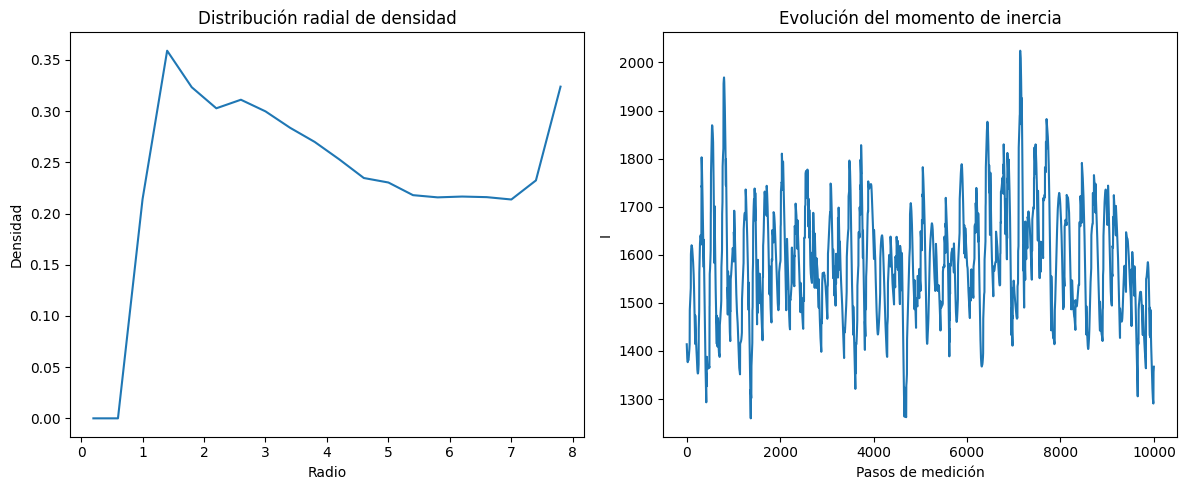

In [8]:
# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================

def main():
    # -------------------------------------------------
    # INICIALIZACIÓN
    # -------------------------------------------------
    pos = np.random.uniform(-R_FRONTERA * 0.6, R_FRONTERA * 0.6, (N_SISTEMAS, 2))
    vel = np.zeros_like(pos)

    for i in range(N_SISTEMAS):
        r = np.linalg.norm(pos[i])
        if r == 0: r = 1e-6
        v_circular = np.sqrt(G * M_AGUJERO_NEGRO / r)
        v_mag = v_circular * np.random.uniform(0.4, 0.8)
        direccion = np.array([-pos[i, 1], pos[i, 0]]) / r
        vel[i] = direccion * v_mag + np.random.normal(0, 0.05, 2)

    acc = get_acc(pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION)
    absorciones = 0
    historial_inercia = []
    historial_densidad = []
    total_steps = PASOS_ESTABILIZACION + PASOS_MEDICION
    pos_save = np.zeros((N_SISTEMAS, 2, COLA))

    # Variable para acumular el tiempo de cálculo puro
    tiempo_calculo_puro = 0.0

    print("Fase 1: Calculando simulación y fotogramas...")

    fig, ax_anim = plt.subplots(figsize=(6, 6))
    ax_anim.set_xlim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_ylim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_aspect("equal")
    fotogramas = []

    # -------------------------------------------------
    # BUCLE TEMPORAL (VERLET)
    # -------------------------------------------------
    for step in range(total_steps):

        # INICIO DEL CRONÓMETRO DE CÁLCULO
        t_start = time.time()

        v_half = vel + acc * DT / 2.0
        pos += v_half * DT
        idx = step % COLA
        pos_save[:, :, idx] = pos

        for i in range(N_SISTEMAS):
            r_mag = np.linalg.norm(pos[i])
            if r_mag < R_ABSORCION or r_mag > R_FRONTERA:
                if step >= PASOS_ESTABILIZACION and r_mag < R_ABSORCION:
                    absorciones += 1
                theta = np.random.uniform(0, 2 * np.pi)
                pos[i] = R_FRONTERA * np.array([np.cos(theta), np.sin(theta)])
                v_circular = np.sqrt(G * M_AGUJERO_NEGRO / R_FRONTERA)
                v_reg = v_circular * np.random.uniform(0.4, 0.8)
                direccion = np.array([-pos[i, 1], pos[i, 0]]) / R_FRONTERA
                vel[i] = direccion * v_reg + np.random.normal(0, 0.2, 2)
                v_half[i] = vel[i]

        resolver_colisiones(pos, v_half, R_COLISION)
        acc_new = get_acc(pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION)
        vel = v_half + acc_new * DT / 2.0
        acc = acc_new

        if step >= PASOS_ESTABILIZACION:
            I = np.sum(M_SISTEMA * np.sum(pos**2, axis=1))
            historial_inercia.append(I)
            radios = np.linalg.norm(pos, axis=1)
            counts, bins = np.histogram(radios, bins=20, range=(0, R_FRONTERA))
            areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
            densidad = counts * M_SISTEMA / areas
            historial_densidad.append(densidad)

        # FIN DEL CRONÓMETRO DE CÁLCULO (Se suma al acumulador)
        tiempo_calculo_puro += (time.time() - t_start)

        # -------------------------------------------------
        # VISUALIZACIÓN (Excluida del tiempo de cálculo)
        # -------------------------------------------------
        if step % 40 == 0:
            elementos_fotograma = []
            for i in range(N_SISTEMAS):
                if step < COLA:
                    trayectoria = pos_save[i, :, :step]
                else:
                    trayectoria = np.concatenate((pos_save[i, :, idx:], pos_save[i, :, :idx]), axis=1)
                if trayectoria.shape[1] > 0:
                    pts_tray = ax_anim.scatter(trayectoria[0], trayectoria[1], s=3, color='blue', alpha=0.3)
                    elementos_fotograma.append(pts_tray)

            pts_pos = ax_anim.scatter(pos[:, 0], pos[:, 1], s=10, color='red')
            pts_bh = ax_anim.scatter(0, 0, s=80, color='black')
            elementos_fotograma.extend([pts_pos, pts_bh])
            fotogramas.append(elementos_fotograma)

    print("Compilando animación...")
    ani = animation.ArtistAnimation(fig, fotogramas, interval=50, blit=True)
    ani.save("simulacion.gif", writer="pillow")
    plt.close(fig)

    # -------------------------------------------------
    # RESULTADOS
    # -------------------------------------------------
    tiempo_fisico_simulado = PASOS_MEDICION * DT
    densidad_media = np.mean(historial_densidad, axis=0)
    inercia_media = np.mean(historial_inercia)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    print("\n--- INFORME DE RENDIMIENTO ---")
    print(f"TIEMPO EXCLUSIVO DE CÁLCULO FÍSICO: {tiempo_calculo_puro:.4f} segundos")
    print(f"Promedio por paso de tiempo: {tiempo_calculo_puro/total_steps:.6f} segundos")

    print("\n--- RESULTADOS FÍSICOS ---")
    print("Absorciones totales:", absorciones)
    print("Tiempo físico simulado:", tiempo_fisico_simulado)
    print("Flujo medio de masa:", (absorciones * M_SISTEMA) / tiempo_fisico_simulado)
    print("Momento de inercia medio:", inercia_media)

    # Gráficas finales
    fig_res, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(bin_centers, densidad_media)
    ax1.set_title("Distribución radial de densidad")
    ax1.set_xlabel("Radio"); ax1.set_ylabel("Densidad")
    ax2.plot(historial_inercia)
    ax2.set_title("Evolución del momento de inercia")
    ax2.set_xlabel("Pasos de medición"); ax2.set_ylabel("I")
    plt.tight_layout()
    plt.savefig("analisis_galaxia.png")
    plt.show()

if __name__ == "__main__":
    main()

**Implementación del código optimizado con Numba**

La simulación de N cuerpos puede llegar a ser computacionalmente muy costosa cuando N es lo suficientemente grande. Las interacciones par a par escalan con $O(N^2)$. Para sistemas con una gran cantidad de partículas, la eficiencia es crítica. Numba es una excelente opción para optimizar el código de Python, ya que compila funciones Python a código máquina nativo utilizando el compilador LLVM. Esto puede resultar en aceleraciones de rendimiento comparables a las de C, sin necesidar de transcribir el código a este lenguaje.

En esta optimización, se ha utilizado el decorador `@njit(fastmath=True)` de Numba en las funciones `get_acc_numba` y `resolver_colisiones_numba` para acelerar drásticamente los cálculos de aceleración y detección de colisiones, que son los cuellos de botella principales de la simulación. Además, se han ajustado algunos parámetros físicos para un escenario galáctico más realista.

Calculando 10000 pasos
Generando simulación...
Generando gráficas de análisis...
Éxito. Archivos guardados.


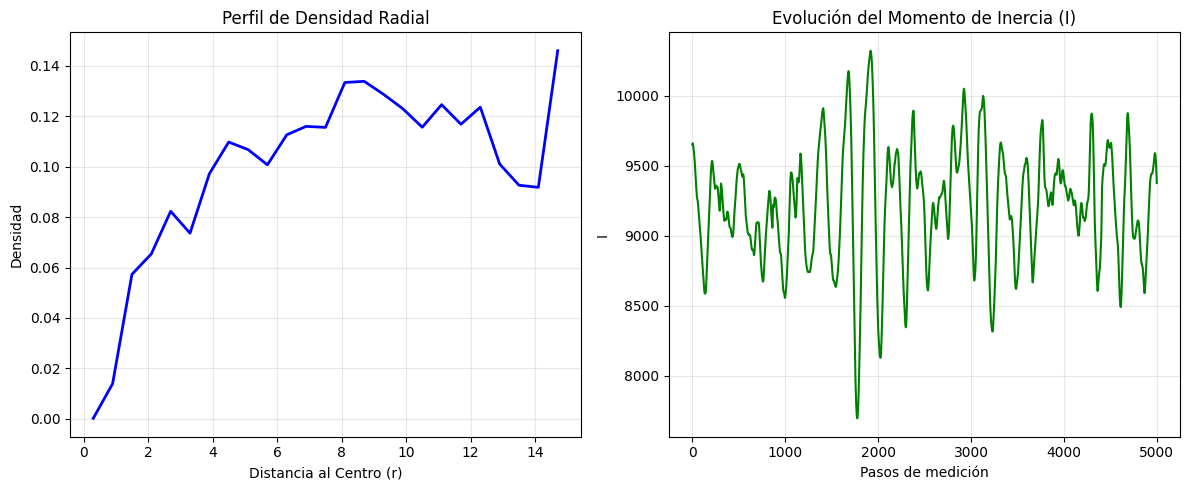

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import os
from numba import njit

# =============================================================================
# PARÁMETROS FÍSICOS (VALORES REALISTAS)
# =============================================================================
N_SISTEMAS = 80
G = 1.0
M_AGUJERO_NEGRO = 4.1e6  # Masa de Sagitario A* en masas solares
M_SISTEMA = 1.0          # Masa de un sistema estelar (1 masa solar)
R_COLISION = 0.06
R_ABSORCION = 0.5
R_FRONTERA = 15.0        # Ampliado para la escala galáctica
DIST_INTERACCION = 5.0
DT = 0.0005              # Reducido para manejar la enorme fuerza central
SOFTENING = 0.2          # Aumentado para evitar divergencias numéricas
PASOS_ESTABILIZACION = 5000
PASOS_MEDICION = 5000
COLA = 150

# RUTA DE GUARDADO
OUTPUT_DIR = r"C:\Users\Usuario\Desktop\2526_Computacional\voluntario1"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# =============================================================================
# FUNCIONES OPTIMIZADAS
# =============================================================================

@njit(fastmath=True)
def get_acc_numba(pos, mass, m_bh, r_limit, softening, G_const):
    n = pos.shape[0]
    acc = np.zeros_like(pos)
    for i in range(n):
        rx, ry = pos[i, 0], pos[i, 1]
        r_sq = rx**2 + ry**2
        r_mag = np.sqrt(r_sq)
        # Fuerza del Agujero Negro Central
        factor_bh = -G_const * m_bh / (r_sq * r_mag + softening)
        acc[i, 0], acc[i, 1] = rx * factor_bh, ry * factor_bh

        # Interacciones entre sistemas (N-cuerpos limitado por r_limit)
        for j in range(i + 1, n):
            dx, dy = pos[j, 0] - pos[i, 0], pos[j, 1] - pos[i, 1]
            d_sq = dx**2 + dy**2
            dist = np.sqrt(d_sq)
            if dist < r_limit and dist > 0:
                f_mag = G_const * mass / (d_sq * dist + softening)
                acc[i, 0] += f_mag * dx; acc[i, 1] += f_mag * dy
                acc[j, 0] -= f_mag * dx; acc[j, 1] -= f_mag * dy
    return acc

@njit(fastmath=True)
def resolver_colisiones_numba(pos, vel, r_col):
    n, r_double = pos.shape[0], 2 * r_col
    for i in range(n):
        for j in range(i + 1, n):
            dx, dy = pos[j, 0] - pos[i, 0], pos[j, 1] - pos[i, 1]
            d_sq = dx**2 + dy**2
            if d_sq < r_double**2 and d_sq > 0:
                dist = np.sqrt(d_sq)
                nx, ny = dx / dist, dy / dist
                rvx, rvy = vel[j, 0] - vel[i, 0], vel[j, 1] - vel[i, 1]
                v_imp = rvx * nx + rvy * ny
                if v_imp < 0:
                    vel[i, 0] += v_imp * nx; vel[i, 1] += v_imp * ny
                    vel[j, 0] -= v_imp * nx; vel[j, 1] -= v_imp * ny

# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================

def main():
    # Inicialización de posiciones y velocidades circulares
    pos = np.random.uniform(-R_FRONTERA * 0.7, R_FRONTERA * 0.7, (N_SISTEMAS, 2))
    vel = np.zeros_like(pos)
    for i in range(N_SISTEMAS):
        r = np.sqrt(pos[i,0]**2 + pos[i,1]**2) or 1e-6
        v_mag = np.sqrt(G * M_AGUJERO_NEGRO / r) * np.random.uniform(0.7, 0.9)
        vel[i] = np.array([-pos[i, 1], pos[i, 0]]) / r * v_mag + np.random.normal(0, 0.1, 2)

    acc = get_acc_numba(pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION, SOFTENING, G)
    total_steps = PASOS_ESTABILIZACION + PASOS_MEDICION

    historial_inercia = []
    historial_densidad = []
    fotogramas = []

    fig_anim, ax_anim = plt.subplots(figsize=(7, 7))
    print(f"Calculando {total_steps} pasos")

    # Bucle Temporal (Verlet en Velocidad)
    for step in range(total_steps):
        # 1. Actualización de posición
        v_half = vel + acc * DT / 2.0
        pos += v_half * DT

        # 2. Gestión de fronteras y absorción
        for i in range(N_SISTEMAS):
            r_mag = np.sqrt(pos[i,0]**2 + pos[i,1]**2)
            if r_mag < R_ABSORCION or r_mag > R_FRONTERA:
                theta = np.random.uniform(0, 2 * np.pi)
                pos[i] = R_FRONTERA * np.array([np.cos(theta), np.sin(theta)])
                v_reg = np.sqrt(G * M_AGUJERO_NEGRO / R_FRONTERA) * np.random.uniform(0.8, 0.95)
                vel[i] = np.array([-pos[i, 1], pos[i, 0]]) / R_FRONTERA * v_reg
                v_half[i] = vel[i]

        # 3. Colisiones y nueva aceleración
        resolver_colisiones_numba(pos, v_half, R_COLISION)
        acc_new = get_acc_numba(pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION, SOFTENING, G)
        vel = v_half + acc_new * DT / 2.0
        acc = acc_new

        # 4. Toma de datos en fase de medición
        if step >= PASOS_ESTABILIZACION:
            # Momento de inercia: I = sum(m * r^2)
            I = np.sum(M_SISTEMA * np.sum(pos**2, axis=1))
            historial_inercia.append(I)

            # Densidad radial
            radios = np.sqrt(np.sum(pos**2, axis=1))
            counts, bins = np.histogram(radios, bins=25, range=(0, R_FRONTERA))
            areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
            densidad = counts * M_SISTEMA / areas
            historial_densidad.append(densidad)

        # Captura de fotogramas para el GIF
        if step % 80 == 0:
            p_pos = ax_anim.scatter(pos[:, 0], pos[:, 1], s=8, color='crimson', animated=True)
            p_bh = ax_anim.scatter(0, 0, s=100, color='black', animated=True)
            fotogramas.append([p_pos, p_bh])

    # --- GUARDADO DE RESULTADOS ---

    # 1. Guardar GIF
    print("Generando simulación...")
    ax_anim.set_xlim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_ylim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_title("Dinámica Galáctica (Verlet + Numba)")
    ani = animation.ArtistAnimation(fig_anim, fotogramas, interval=40, blit=True)
    ani.save(os.path.join(OUTPUT_DIR, "simulacion_opt.gif"), writer="pillow")
    plt.close(fig_anim)

    # 2. Generar y guardar Gráfica de Análisis
    print("Generando gráficas de análisis...")
    densidad_media = np.mean(historial_densidad, axis=0)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    fig_res, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(bin_centers, densidad_media, color='blue', lw=2)
    ax1.set_title("Perfil de Densidad Radial")
    ax1.set_xlabel("Distancia al Centro (r)"); ax1.set_ylabel("Densidad")
    ax1.grid(True, alpha=0.3)

    ax2.plot(historial_inercia, color='green')
    ax2.set_title("Evolución del Momento de Inercia (I)")
    ax2.set_xlabel("Pasos de medición"); ax2.set_ylabel("I")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "analisis_galaxia_opt.png"))
    print(f"Éxito. Archivos guardados.")

if __name__ == "__main__":
    main()

## **Conclusión**
El algoritmo de Verlet en Velocidad ha demostrado ser fundamental para esta simulación de $N$ cuerpos por su capacidad inherente para conservar la energía y el momento angular del sistema. Aunque nuestro modelo incluye disipación (colisiones elásticas) e reintroducción de partículas en la frontera, Verlet ofrece una estabilidad temporal superior a otros métodos, garantizando que la dinámica observada sea robusta y refleje las interacciones gravitatorias con fidelidad a la realidad.
Su eficiencia computacional también es un factor decisivo, especialmente al combinarlo con optimizaciones como Numba, que ha permitido escalar a un número mayor de sistemas solares y realizar simulaciones más extensas en tiempos razonables.

El análisis de los resultados, tanto de la simulación como de su versión optimizada, revela patrones interesantes. La distribución radial de densidad muestra cómo se distribuye la masa desde el centro hasta la periferia. Vemos que la densidad es prácticamente cero en la región central. Desde el punto de vista de la astrofísica real, en una galaxia, la densidad aumenta exponencialmente conforme el observador se acerca al centro; sin embargo, en la simulación se observa justamente lo contrario por una razón muy concreta: el sumidero. Cuando una partícula se acerca al centro, esta es absorbida, por lo que es imposible que se acumule la densidad en el núcleo. Por otro lado, aunque el agujero negro es masivo, se considera como una masa puntual, por tanto no aporta datos a la gráfica de densidad de los sistemas solares. En el extremo opuesto, se observa un pico de densidad al final de la gráfica; esto se debe a que, cuando un sistema es absorbido y reintroducido en la frontera, se genera una acumulación artificial de masa en el borde.

Asimismo, la evolución del momento de inercia ($I$) nos da información sobre la estabilidad del sistema. Las fluctuaciones a lo largo del tiempo se pueden asociar nuevamente a la dinámica de absorción y reintroducción de cuerpos. Los picos se deben a que, cuando un sistema solar pasa de estar cerca del centro a la periferia, su contribución individual aumenta drásticamente debido a la dependencia cuadrática del radio en la fórmula $I = \sum m_i r_i^2$. Por contraparte, los valles representan la masa cayendo hacia el pozo gravitatorio, reduciendo por tanto su inercia global. A pesar de estas fluctuaciones, podemos ver que la galaxia alcanza un estado estacionario dinámico: la cantidad de masa que "muere" en el centro es compensada con la que "nace" en el borde.

En definitiva, las discrepancias observadas respecto a los perfiles galácticos reales no invalidan el experimento, sino que validan de forma lógica las condiciones de contorno impuestas (sumidero y frontera).